## Pengolahan Citra Digital

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import math

### Import or Read Image

image shape: 
height: 250 
width: 250 
channel: 3


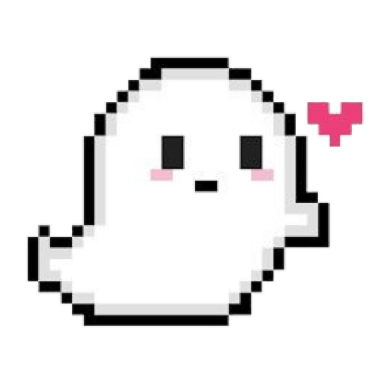

In [11]:
img_bgr = cv2.imread("cute-ghost.png")
h, w, c = img_bgr.shape
print(f'image shape: \nheight: {h} \nwidth: {w} \nchannel: {c}')

# as default, cv2 read image to be BGR not RGB, so we have to convert it manually.
# BGR to RGB
img = np.zeros_like(img_bgr)
img[:, :, 0] = img_bgr[:, :, 2]
img[:, :, 1] = img_bgr[:, :, 1]
img[:, :, 2] = img_bgr[:, :, 0]

plt.imshow(img)
plt.axis("off")
plt.show()

### Image Translation

Image Translation is the process of shifting an image from one location to another in the coordinate plane without rotating or flipping it. \
It simply moves every pixel by a certain distance in the x and y directions.
- <b>Horizontal Shift</b>
    For an image shifted right by `tx` pixels:
$$ (x, y) = (x + tx, y) $$

- <b>Vertical Shift</b>
    For an image shifted downward by `ty` pixels:
$$ (x, y) = (x, y + ty) $$

- <b>General Translation</b>
    For both horizontal and vertical shifts:
$$ (x, y) = (x + tx, y+ ty) $$

In [ ]:
# translate image
def translate_image(img, tx=0, ty=0):
    shift_img = np.zeros_like(img)
    h, w, c = shift_img.shape

    for i in range(h):
        for j in range(w):
            new_i = i + ty
            new_j = j + tx

            if 0 <= new_i < h and 0 <= new_j < w:
                shift_img[new_i, new_j] = img[i, j]
    
    return shift_img

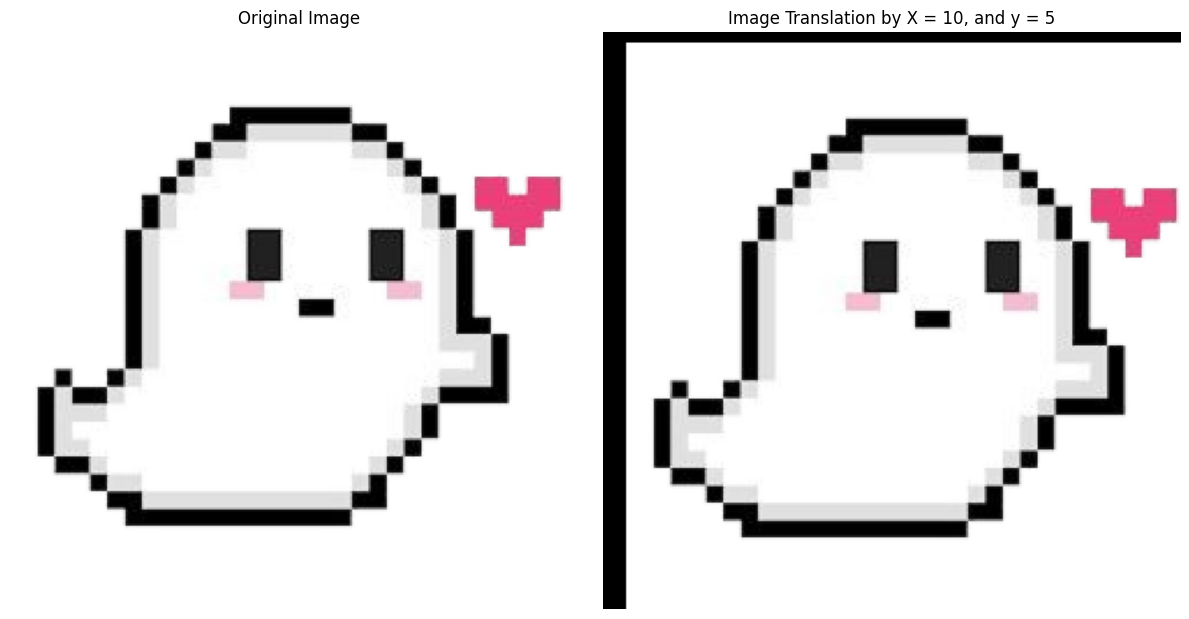

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

axs[0].imshow(img)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(translate_image(img, tx=10, ty=5))
axs[1].set_title("Image Translation by X = 10, and y = 5")
axs[1].axis("off")

plt.tight_layout()
plt.show()

### Image Scaling

#### Enlargment 

In [ ]:
# enlargement image
def enlargement_image(img, sx=1, sy=1):
    h, w, c = img.shape

    new_h = int(h * sy)
    new_w = int(w * sx)
    enlarge_img = np.zeros((new_h, new_w, c), dtype=img.dtype)

    for i in range(new_h):
        for j in range(new_w):
            y = int(i / sy)
            x = int(j / sx)

            enlarge_img[i, j] = img[y, x]

    return enlarge_img

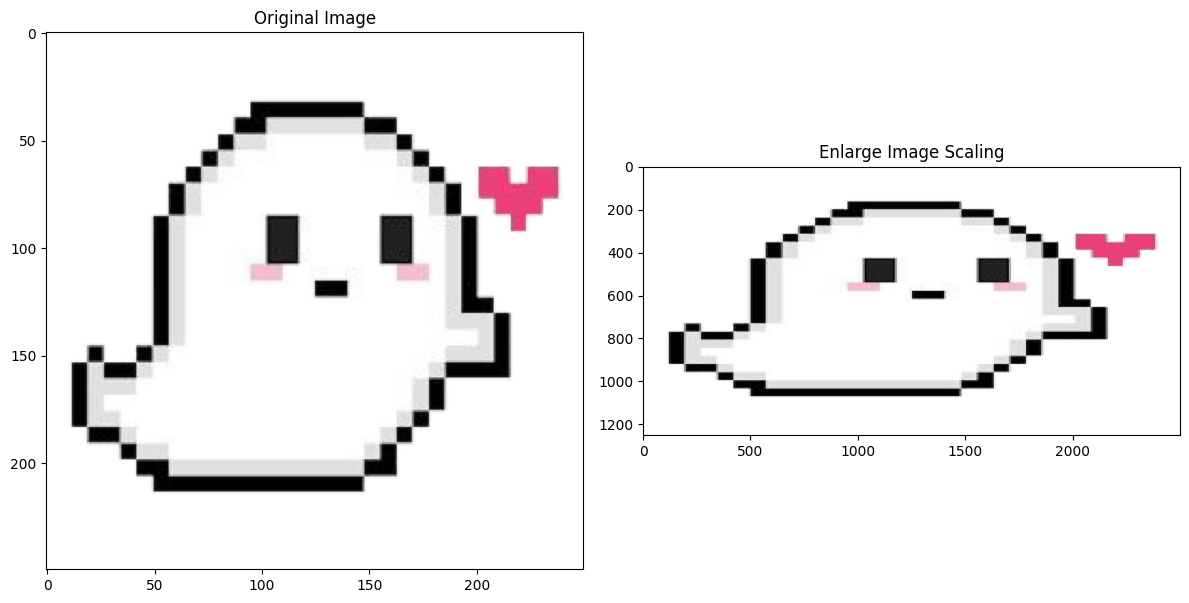

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

axs[0].imshow(img)
axs[0].set_title("Original Image")

axs[1].imshow(enlargement_image(img, sx=10, sy=5))
axs[1].set_title("Enlarge Image Scaling")

plt.tight_layout()
plt.show()

### Mirroring Image

Mirroing image is the process of flipping an image across an axis (horizontal or vertical).
It’s like reflecting the image as if in a mirror.

- <b>Horizontal Mirror</b> \
For image with width `W`, the formula is:
$$ (x,y)⟶(W−1−x, y) $$

- <b>Vertical Mirror</b> \
For image with height `H`, the formula is:
$$ (x,y)⟶(x, H-1-y) $$

- <b>Combination Mirror</b> \
Combination of horizontal and vertical mirror. \
For width `W` and height `H`, the formula is:
$$ (x,y)⟶(W-1-x, H-1-y) $$

In [ ]:
# mirror image
def horizontal_mirror(img):
    mirrored_img = np.zeros_like(img)
    h, w, c = img.shape

    for i in range(h):
        for j in range(w):
            mirrored_img[j, i] = img[w-j-1, i]
    return mirrored_img 
    
def vertical_mirror(img):
    mirrored_img = np.zeros_like(img)
    h, w, c = img.shape

    for i in range(h):
        for j in range(w):
            mirrored_img[i, j] = img[i, h-j-1]
    return mirrored_img

def combination_mirror(img):
    mirrored_img = np.zeros_like(img)
    h, w, c = img.shape

    for i in range(h):
        for j in range(w):
            mirrored_img[i, j] = img[h-i-1, w-j-1]
    return mirrored_img

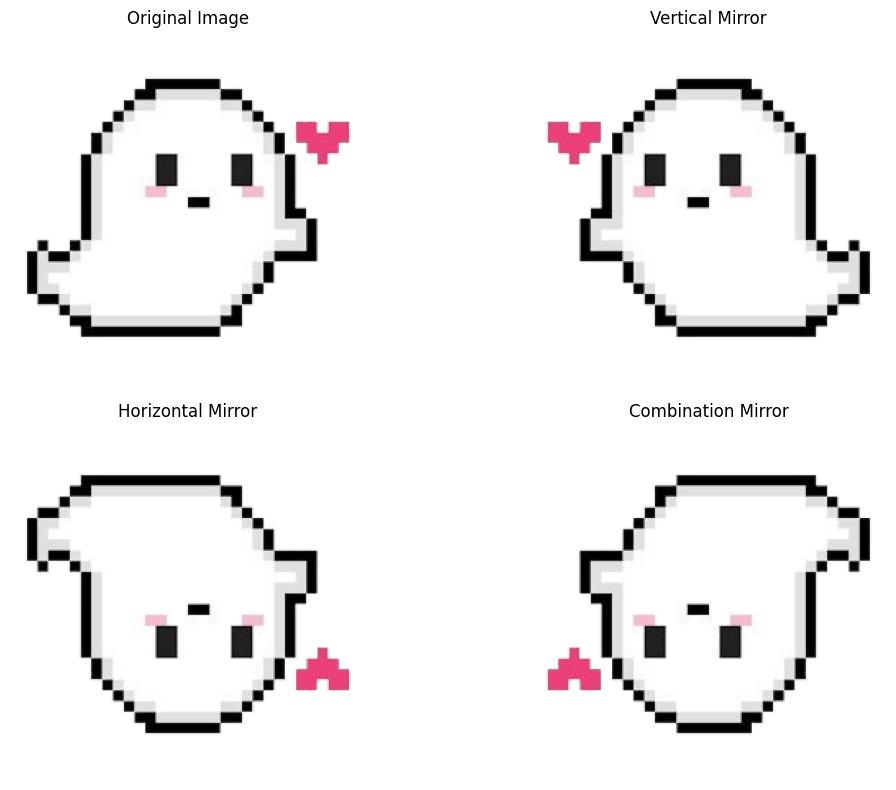

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img)
axs[0, 0].set_title("Original Image")
axs[0, 0].axis("off")

axs[0, 1].imshow(vertical_mirror(img))
axs[0, 1].set_title("Vertical Mirror")
axs[0, 1].axis("off")

axs[1, 0].imshow(horizontal_mirror(img))
axs[1, 0].set_title("Horizontal Mirror")
axs[1, 0].axis("off")

axs[1, 1].imshow(combination_mirror(img))
axs[1, 1].set_title("Combination Mirror")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

### Rotating Image

Rotating an image is the process of turning the image around its center or a chosen axis by a certain angle. \
It’s like spinning the image on a coordinate plane.

- Clockwise rotation
$$ (x, y) = ((x−a)cosθ+(y−b)sinθ+a, −(x−a)sinθ+(y−b)cosθ+b) $$


In [54]:
# rotate image
def rotate_image(img, angle=0):
    
    rad = np.deg2rad(angle)
    cos_a = math.cos(rad)
    sin_a = math.sin(rad)

    new_h = int(abs(w * sin_a) + abs(h * cos_a))
    new_w = int(abs(w * cos_a) + abs(h * sin_a))

    rotated_image = np.zeros((new_h, new_w, c), dtype=np.uint8)

    # center coordinates
    cx, cy = w // 2, h // 2
    ncx, ncy = new_w // 2, new_h // 2

    for i in range(new_h):
        for j in range(new_w):
            # shift to center
            x = (j - ncx)
            y = (i - ncy)

            # inverse rotation
            src_x = int(x * cos_a + y * sin_a + cx)
            src_y = int(-x * sin_a + y * cos_a + cy)

            # check bounds
            if 0 <= src_x < w and 0 <= src_y < h:
                rotated_image[i, j] = img[src_y, src_x]

    return rotated_image

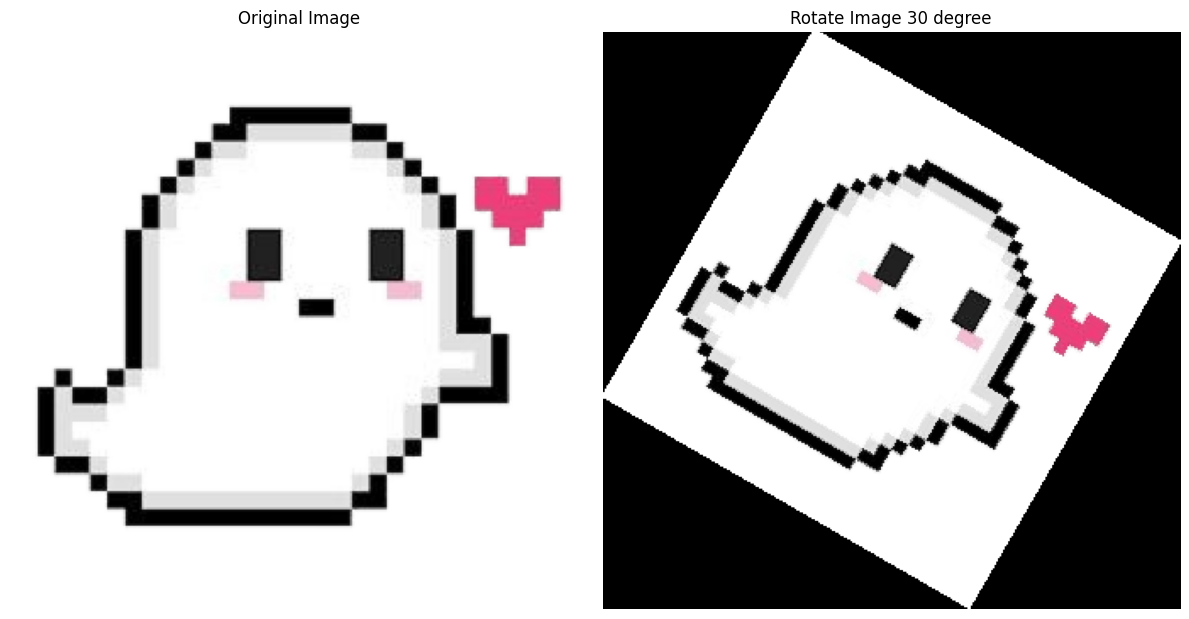

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(6, 4))

axs[0].imshow(img)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(rotate_image(img, 30))
axs[1].set_title("Rotate Image 30 degree")
axs[1].axis("off")

plt.tight_layout()
plt.show()

### Negative Image

Negative image is the process of inverting the pixel values of an image, so that light areas become dark and dark areas become light. \
It’s like flipping brightness on a grayscale or color scale.

- Negative transformation:
$$ I′(x,y)=L−1−I(x,y) $$

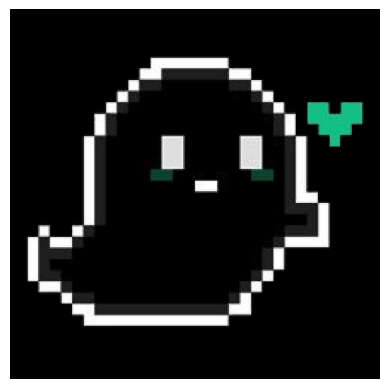

In [9]:
def negative_image(img):
    neg_img = 255 - img
    return neg_img

plt.imshow(negative_image(img))
plt.axis("off")
plt.show()

### Grayscale Image

In [ ]:
def grayscale_image(img):
    h, w, c = img.shape
    gray_img = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            r, g, b = img[i, j]
            gray = int(0.299 * r + 0.587 * g + 0.114 * b)
            gray_img[i, j] = gray

    return gray_img

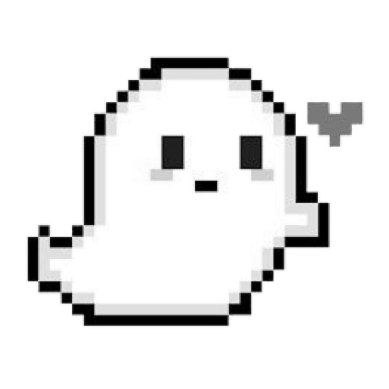

In [11]:
plt.imshow(grayscale_image(img), cmap='gray')
plt.axis("off")
plt.show()

### Ripple

In [48]:
def ripple_image(img, ax=1, ay=1, tx=1, ty=1):
    ripple_img = np.zeros_like(img)
    h, w, c = ripple_img.shape

    for i in range(h):
        for j in range(w):
            new_i = i + int(ay * math.sin(2 * math.pi * j / ty))
            new_j = j + int(ax * math.sin(2 * math.pi * i / tx))

            if 0 <= new_i < h and 0 <= new_j < w:
                ripple_img[new_i, new_j] = img[i, j]

    return ripple_img

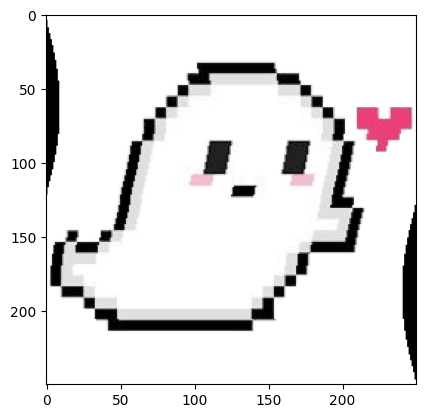

In [49]:
plt.imshow(ripple_image(img, 10, 0, 250, 1))
plt.show()

### Thresholding Image

In [12]:
def thresholding_image(img, threshold = 128):
    gray_img = grayscale_image(img)
    thresh_img = np.zeros_like(gray_img)

    h, w = gray_img.shape

    for i in range(h):
        for j in range(w):
            if gray_img[i, j] >= threshold:
                thresh_img[i, j] = 255
            else:
                thresh_img[i, j] = 0
    return thresh_img

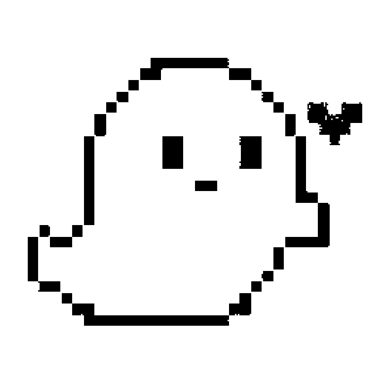

In [13]:
plt.imshow(thresholding_image(img), cmap='gray')
plt.axis("off")
plt.show()

### Negative + Thresholding = 50

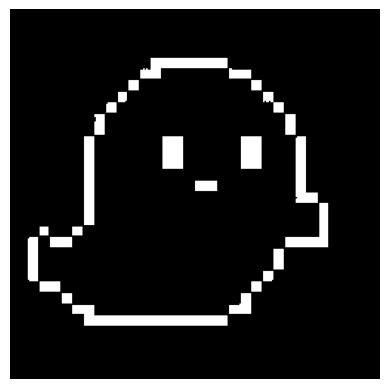

In [14]:
plt.imshow(negative_image(thresholding_image(img, threshold=50)), cmap='gray')
plt.axis("off")
plt.show()

### Scaling Image

In [15]:
def scaling_image(img, x_scale = 1, y_scale=1):
    h, w, c = img.shape
    new_h = int(h * y_scale)
    new_w = int(w * x_scale)
    new_image = np.zeros((new_h, new_w, c), dtype=np.uint8)

    for i in range(new_h):
        for j in range(new_w):
            src_x = int(j / x_scale)
            src_y = int(i / y_scale)

            if 0 <= src_x < w and 0 <= src_y < h:
                new_image[i, j] = img[src_y, src_x]

    return new_image

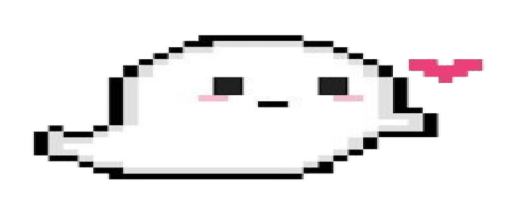

In [16]:
plt.imshow(scaling_image(img, 5, 2))
plt.axis("off")
plt.show()

### Gaussian Blur

In [17]:
# Gaussian Blur
def gaussian_blur(image, radius):
    sigma = max(radius / 2, 1.0)
    kernel_size = int(2 * radius + 1)

    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float64)
    sum_val = 0.0

    for x in range(-radius, radius + 1):
        for y in range(-radius, radius + 1):
            exponent = -(x**2 + y**2) / (2 * sigma**2)
            value = (1 / (2 * math.pi * sigma**2)) * math.exp(exponent)
            kernel[x + radius, y + radius] = value
            sum_val += value

    kernel /= sum_val

    h, w, c = image.shape
    output = np.zeros_like(image, dtype=np.float64)

    for y in range(radius, h - radius):
        for x in range(radius, w - radius):
            region = image[y - radius:y + radius + 1, x - radius:x + radius + 1]
            for ch in range(c):
                output[y, x, ch] = np.sum(region[:, :, ch] * kernel)
    
    return output.astype(np.uint8)

(250, 250, 3)


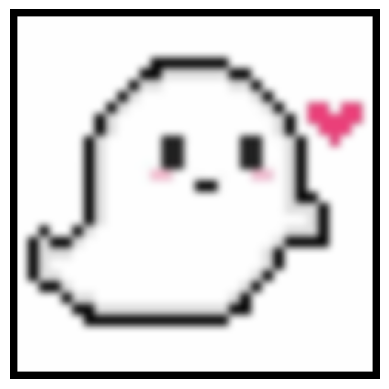

In [18]:
gaussian_blur_image = gaussian_blur(img, 5)
print(gaussian_blur_image.shape)

plt.imshow(gaussian_blur(img, 5))
plt.axis("off")
plt.show()

### Interpolation

#### Nearest Neighbor Interpolation

Nearest Neighbor Interpolation works by copying the value of the closest pixel. \
This interpolation is fast, but it produces a blocky / pixelated result. \
The formula for this interpolation is: 
$$ I'(x', y') = I(round(x), round(y)) $$

In [19]:
def nn_interpolation(img, new_width, new_height):
    old_height = len(img)
    old_width = len(img[0])

    x_ratio = old_width / new_width
    y_ratio = old_height / new_height

    new_image = []
    for new_y in range(new_height):
        row = []
        for new_x in range(new_width):
            old_x = int(new_x * x_ratio)
            old_y = int(new_y * y_ratio)

            row.append(img[old_y][old_x])
        new_image.append(row)
    return new_image

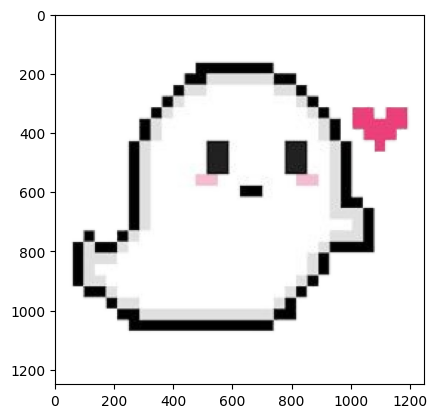

In [22]:
plt.imshow(nn_interpolation(img, 250*5, 250*5))
plt.show()

In [29]:
def resize_bilinear(image, new_width, new_height):
    old_height = len(image)
    old_width = len(image[0])

    # cek jumlah channel (1 = grayscale, >1 = RGB/Multichannel)
    if isinstance(image[0][0], (list, tuple)):
        channels = len(image[0][0])
    else:
        channels = 1

    x_ratio = (old_width - 1) / new_width
    y_ratio = (old_height - 1) / new_height

    new_image = []
    for new_y in range(new_height):
        row = []
        for new_x in range(new_width):
            x_l = int(x_ratio * new_x)
            y_l = int(y_ratio * new_y)
            x_h = min(x_l + 1, old_width - 1)
            y_h = min(y_l + 1, old_height - 1)

            x_weight = (x_ratio * new_x) - x_l
            y_weight = (y_ratio * new_y) - y_l

            a = image[y_l][x_l]
            b = image[y_l][x_h]
            c = image[y_h][x_l]
            d = image[y_h][x_h]

            if channels > 1:  # RGB or multi-channel
                pixel = []
                for ch in range(channels):
                    value = (a[ch] * (1 - x_weight) * (1 - y_weight) +
                             b[ch] * x_weight * (1 - y_weight) +
                             c[ch] * (1 - x_weight) * y_weight +
                             d[ch] * x_weight * y_weight)
                    pixel.append(int(value))
                row.append(pixel)
            else:  # grayscale
                value = (a * (1 - x_weight) * (1 - y_weight) +
                         b * x_weight * (1 - y_weight) +
                         c * (1 - x_weight) * y_weight +
                         d * x_weight * y_weight)
                row.append(int(value))
        new_image.append(row)
    return new_image

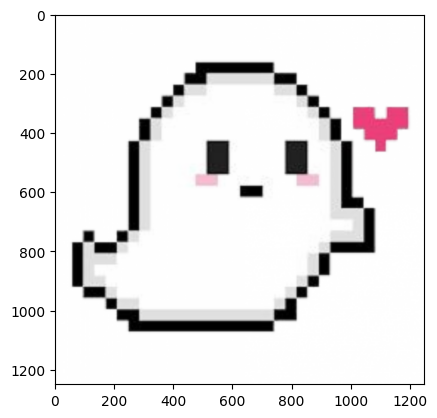

In [32]:
scaled_img = resize_bilinear(img.tolist(), 250*5, 250*5)

plt.imshow(scaled_img)
plt.show()